In [1]:
# =========================
# LOAD DATA (CLEAN)
# =========================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

base_path = "/content/drive/MyDrive/Movie_Predictor/"

movies = pd.read_csv(base_path + "movies.csv")
ratings = pd.read_csv(base_path + "ratings.csv")

print(f"Movies: {movies.shape} | Ratings: {ratings.shape}")

# Basic sanity checks
assert movies["movieId"].is_unique
assert ratings[["userId", "movieId"]].isnull().sum().sum() == 0

display(movies.head(3))
display(ratings.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Movies: (87585, 3) | Ratings: (32000204, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976


#Merge

In [2]:
# =========================
# MERGE CORE DATA
# =========================

df = ratings.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
)

print("Merged shape:", df.shape)
display(df.head())

Merged shape: (32000204, 6)


,userId,movieId,rating,timestamp,title,genres
0,1,17,4.0,944249077,Sense and Sensibility (1995),Drama|Romance
1,1,25,1.0,944250228,Leaving Las Vegas (1995),Drama|Romance
2,1,29,2.0,943230976,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
3,1,30,5.0,944249077,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama
4,1,32,5.0,943228858,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller


#User EDA

In [3]:
# =========================
# USER ACTIVITY
# =========================

user_stats = df.groupby("userId").agg(
    num_ratings=("rating", "count"),
    avg_rating=("rating", "mean"),
    rating_std=("rating", "std")
).reset_index()

display(user_stats.head())

,userId,num_ratings,avg_rating,rating_std
0,1,141,3.531915,1.537870
1,2,52,4.269231,1.122242
2,3,147,3.588435,1.014789
3,4,27,2.629630,1.043225
4,5,33,3.272727,0.910794


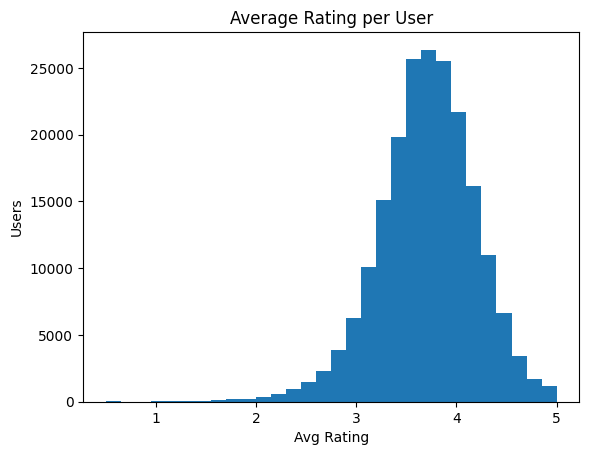

In [4]:
import matplotlib.pyplot as plt

plt.hist(user_stats["avg_rating"], bins=30)
plt.title("Average Rating per User")
plt.xlabel("Avg Rating")
plt.ylabel("Users")
plt.show()

In [5]:
test_user_id = 1

user_history = df[df["userId"] == test_user_id]

print("User history shape:", user_history.shape)

display(
    user_history[["title", "rating", "genres"]]
    .sort_values("rating", ascending=False)
    .head(20)
)

User history shape: (141, 6)


,title,rating,genres
4,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),5.0,Mystery|Sci-Fi|Thriller
3,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,5.0,Crime|Drama
11,"Doom Generation, The (1995)",5.0,Comedy|Crime|Drama
9,Taxi Driver (1976),5.0,Crime|Drama|Thriller
7,"White Balloon, The (Badkonake sefid) (1995)",5.0,Children|Drama
42,Jude (1996),5.0,Drama
41,Secrets & Lies (1996),5.0,Drama
24,Welcome to the Dollhouse (1995),5.0,Comedy|Drama
23,Blade Runner (1982),5.0,Action|Sci-Fi|Thriller
17,Three Colors: Red (Trois couleurs: Rouge) (1994),5.0,Drama


In [6]:
# =========================
# SAMPLE USERS (RECOMMENDED)
# =========================

sample_users = df["userId"].drop_duplicates().sample(5000, random_state=42)

df_sample = df[df["userId"].isin(sample_users)].copy()

print("Sample shape:", df_sample.shape)

Sample shape: (789872, 6)


In [7]:
genre_dummies = df_sample["genres"].str.get_dummies(sep="|")
df_sample = pd.concat([df_sample, genre_dummies], axis=1)

genre_cols = genre_dummies.columns

In [8]:
# =========================
# 1. USER-LEVEL STATS
# =========================

user_stats = df_sample.groupby("userId").agg(
    num_ratings=("rating", "count"),
    avg_rating=("rating", "mean"),
    rating_std=("rating", "std")
).reset_index()

display(user_stats.head())
display(user_stats.describe())

,userId,num_ratings,avg_rating,rating_std
0,5,33,3.272727,0.910794
1,7,44,3.636364,0.966675
2,13,65,3.646154,0.799038
3,34,123,3.626016,0.676277
4,71,29,3.689655,0.890564


,userId,num_ratings,avg_rating,rating_std
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,100408.458000,157.974400,3.698478,0.919179
std,57733.600639,260.579002,0.497514,0.278427
min,5.000000,20.000000,0.785714,0.000000
25%,50888.750000,35.000000,3.406343,0.733364
50%,99572.000000,73.000000,3.716569,0.900929
75%,150428.000000,171.000000,4.020408,1.085942
max,200941.000000,5061.000000,5.000000,2.288464


In [9]:
# =========================
# 2. USER GENRE PREFERENCES
# =========================

pref_df = df_sample.copy()

for col in genre_cols:
    pref_df[col] = pref_df[col] * pref_df["rating"]

user_genre_prefs = pref_df.groupby("userId")[genre_cols].mean().reset_index()

display(user_genre_prefs.head())

,userId,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,5,0.0,1.545455,1.363636,0.333333,0.424242,0.818182,0.787879,0.000000,1.242424,...,0.000000,0.151515,0.333333,0.333333,0.090909,0.454545,0.484848,1.727273,0.363636,0.090909
1,7,0.0,0.931818,0.795455,0.159091,0.522727,1.931818,0.772727,0.113636,1.454545,...,0.000000,0.000000,0.181818,0.159091,0.000000,0.840909,0.431818,0.909091,0.113636,0.159091
2,13,0.0,1.000000,0.430769,0.000000,0.000000,0.846154,0.815385,0.000000,2.261538,...,0.046154,0.169231,0.000000,0.061538,0.246154,1.276923,0.215385,1.569231,0.507692,0.030769
3,34,0.0,0.813008,1.239837,0.304878,0.504065,1.756098,0.227642,0.000000,1.601626,...,0.000000,0.089431,0.065041,0.215447,0.215447,1.276423,0.520325,0.597561,0.097561,0.028455
4,71,0.0,1.241379,0.758621,0.137931,0.310345,1.172414,1.103448,0.000000,1.931034,...,0.000000,0.103448,0.241379,0.137931,0.103448,0.689655,0.206897,1.586207,0.448276,0.241379


#Movie Quality EDA


In [10]:
# =========================
# MOVIE STATS
# =========================

movie_stats = df_sample.groupby("movieId").agg(
    movie_num_ratings=("rating", "count"),
    movie_avg_rating=("rating", "mean")
).reset_index()

In [11]:
# =========================
# MERGE EVERYTHING
# =========================

df_model = df_sample.merge(user_stats, on="userId", how="left")
df_model = df_model.merge(user_genre_prefs, on="userId", how="left", suffixes=("", "_userpref"))
df_model = df_model.merge(movie_stats, on="movieId", how="left")

print(df_model.shape)
display(df_model.head())

(789872, 51)


,userId,movieId,rating,timestamp,title,genres,(no genres listed),Action,Adventure,Animation,...,IMAX_userpref,Musical_userpref,Mystery_userpref,Romance_userpref,Sci-Fi_userpref,Thriller_userpref,War_userpref,Western_userpref,movie_num_ratings,movie_avg_rating
0,5,10,4.0,840768638,GoldenEye (1995),Action|Adventure|Thriller,0,1,1,0,...,0.333333,0.333333,0.090909,0.454545,0.484848,1.727273,0.363636,0.090909,784,3.427296
1,5,47,3.0,840768897,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,0,0,0,0,...,0.333333,0.333333,0.090909,0.454545,0.484848,1.727273,0.363636,0.090909,1520,4.076974
2,5,110,4.0,840768763,Braveheart (1995),Action|Drama|War,0,1,0,0,...,0.333333,0.333333,0.090909,0.454545,0.484848,1.727273,0.363636,0.090909,1719,3.963060
3,5,150,3.0,840763914,Apollo 13 (1995),Adventure|Drama|IMAX,0,0,1,0,...,0.333333,0.333333,0.090909,0.454545,0.484848,1.727273,0.363636,0.090909,1358,3.896171
4,5,153,3.0,840764018,Batman Forever (1995),Action|Adventure|Comedy|Crime,0,1,1,0,...,0.333333,0.333333,0.090909,0.454545,0.484848,1.727273,0.363636,0.090909,847,2.790437


In [12]:
# =========================
# USER x MOVIE MATCH
# =========================

for col in genre_cols:
    df_model[f"user_pref_{col}"] = df_model[f"{col}_userpref"]
    df_model[f"interaction_{col}"] = df_model[col] * df_model[f"user_pref_{col}"]

In [13]:
# =========================
# FEATURES
# =========================

feature_cols = [
    "avg_rating",
    "num_ratings",
    "rating_std",
    "movie_avg_rating",
    "movie_num_ratings"
] + [f"interaction_{col}" for col in genre_cols]

X = df_model[feature_cols].fillna(0)
y = df_model["rating"]

print("X shape:", X.shape)

X shape: (789872, 25)


#Real Model

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 0.8626129624792437


In [15]:
results = pd.DataFrame({
    "actual": y_test,
    "predicted": preds
})

display(results.head(20))

,actual,predicted
532209,4.0,3.168749
712423,4.0,1.183442
98654,1.5,2.741493
698133,5.0,4.109058
493750,4.0,3.303122
147886,4.0,4.395927
382685,4.0,3.656336
382502,4.0,2.994994
493816,2.5,2.667726
416726,3.0,2.493103


#User Results

In [16]:
# =========================
# REBUILD TEST RESULTS WITH USER IDS
# =========================

results = X_test.copy()
results["actual"] = y_test
results["predicted"] = preds

# Add userId back (IMPORTANT)
results["userId"] = df_model.loc[X_test.index, "userId"]

display(results.head())

,avg_rating,num_ratings,rating_std,movie_avg_rating,movie_num_ratings,interaction_(no genres listed),interaction_Action,interaction_Adventure,interaction_Animation,interaction_Children,...,interaction_Musical,interaction_Mystery,interaction_Romance,interaction_Sci-Fi,interaction_Thriller,interaction_War,interaction_Western,actual,predicted,userId
532209,3.864286,910,0.889982,2.718750,112,0.0,1.559890,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.764835,1.455495,0.0,0.0,4.0,3.168749,135999
712423,1.099515,1236,1.409844,3.218194,731,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.070793,0.000000,0.000000,0.0,0.0,4.0,1.183442,179712
98654,3.281192,537,1.010708,2.947368,57,0.0,1.105214,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,1.5,2.741493,25622
698133,3.727273,22,1.411916,4.037037,27,0.0,1.818182,0.0,0.886364,0.0,...,0.0,0.0,0.000000,1.113636,0.000000,0.0,0.0,5.0,4.109058,176076
493750,2.971845,515,0.674496,3.923952,835,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,4.0,3.303122,125501


In [17]:
# =========================
# USER-LEVEL RMSE
# =========================

user_performance = results.groupby("userId").apply(
    lambda x: np.sqrt(np.mean((x["actual"] - x["predicted"])**2))
).reset_index(name="user_rmse")

display(user_performance.head())

/tmp/ipykernel_7552/450861207.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_performance = results.groupby("userId").apply(


,userId,user_rmse
0,5,0.607155
1,7,0.926019
2,13,0.756667
3,34,0.733463
4,71,0.704713


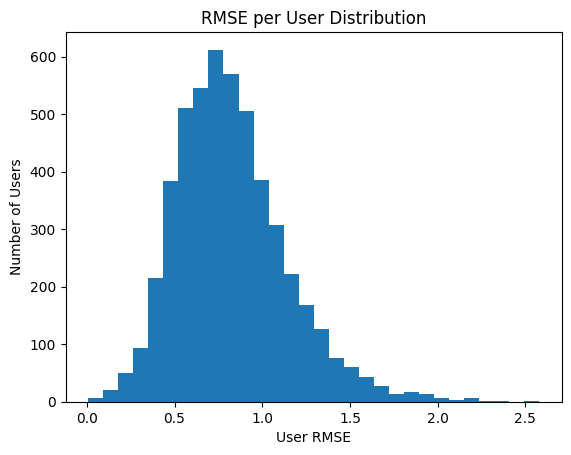

In [18]:
import matplotlib.pyplot as plt

plt.hist(user_performance["user_rmse"], bins=30)
plt.title("RMSE per User Distribution")
plt.xlabel("User RMSE")
plt.ylabel("Number of Users")
plt.show()

In [19]:
# Best predicted users
best_users = user_performance.sort_values("user_rmse").head(10)

# Worst predicted users
worst_users = user_performance.sort_values("user_rmse", ascending=False).head(10)

display(best_users)
display(worst_users)

,userId,user_rmse
3816,153220,0.008058
2737,109646,0.025383
3552,143621,0.031517
52,2153,0.036402
399,16531,0.043319
951,39058,0.051809
3908,157201,0.084779
1768,71092,0.096369
1285,52286,0.107263
2724,109210,0.107291


,userId,user_rmse
1216,50032,2.577935
4349,174309,2.494228
3855,154696,2.325838
3830,153788,2.249735
3775,151847,2.227826
4251,170610,2.218577
4022,161696,2.183301
4389,176024,2.176243
2744,109897,2.171310
1819,72966,2.161338


In [26]:
results["movieId"] = df_model.loc[X_test.index, "movieId"]

In [24]:
display(
    user_results.sort_values("actual", ascending=False)[["actual", "predicted"]]
    .head(15)
)

,actual,predicted
24,4.0,2.878393
6,4.0,3.282772
31,3.0,3.739069
7,3.0,2.893123
18,3.0,2.702929
14,3.0,3.065713
32,3.0,3.397280
